### Steady state induction motor simulation.
 We aim to produce same results than Quanscient Allsolve demo "https://allsolve.quanscient.com/documentation/learn-by-doing/example-cases/electric-motors/em-002-im-2d"

We use same geometry:

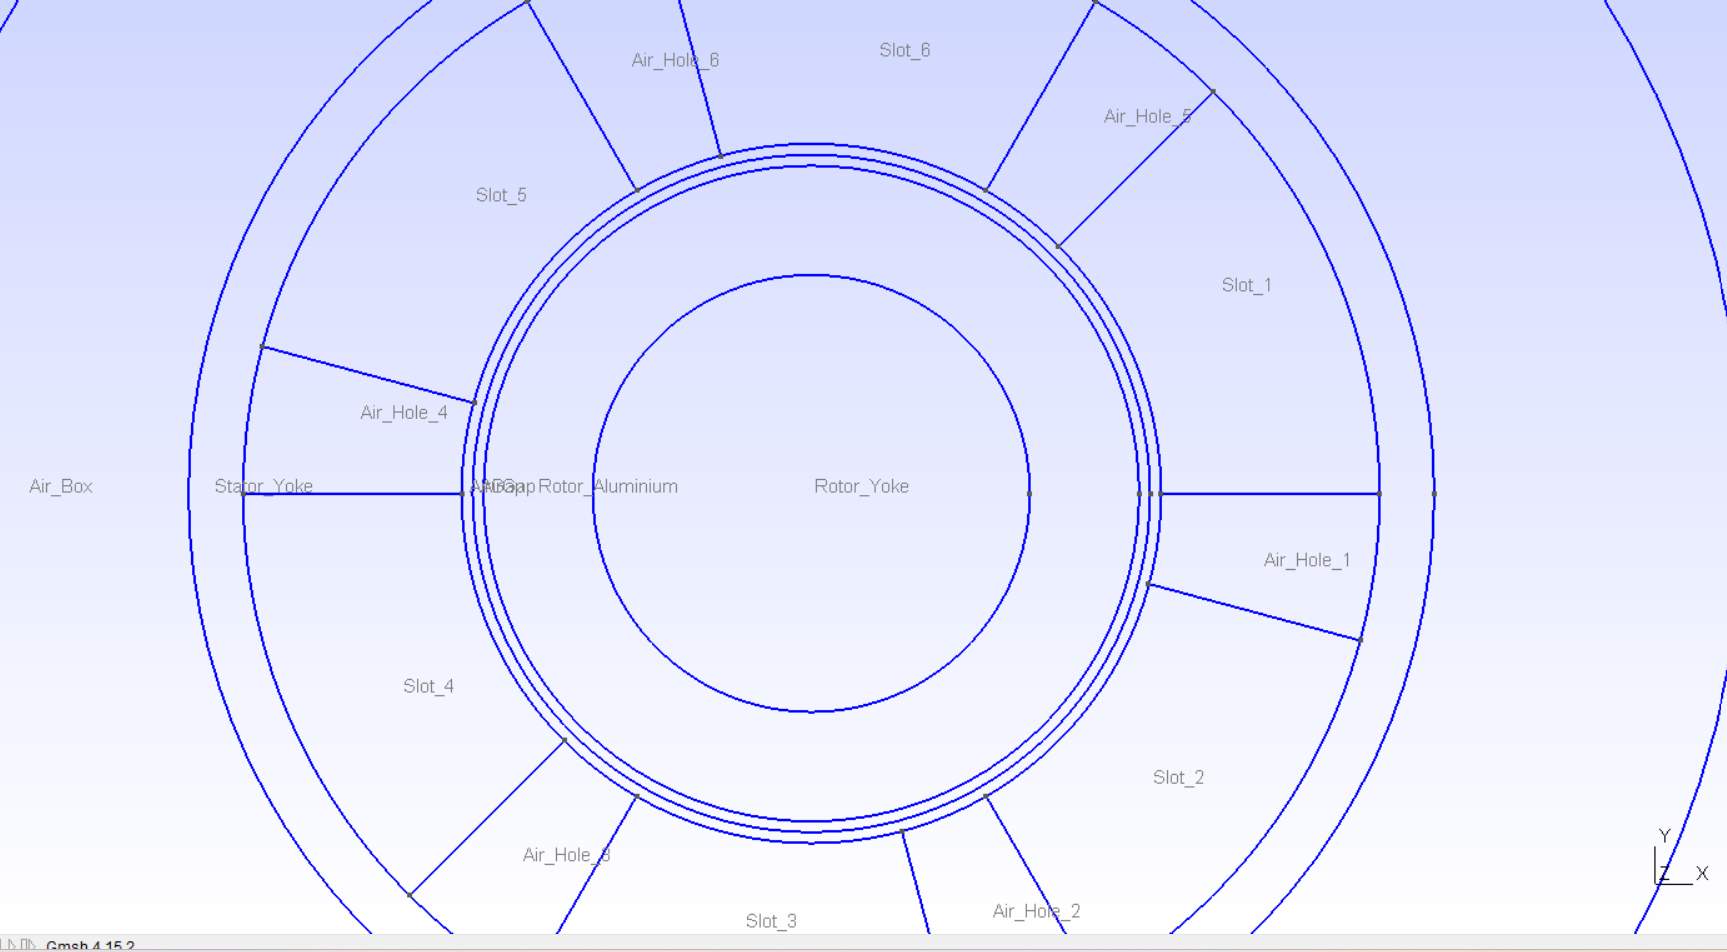

Lets first try to check that our formulation works with solving the torque of 0 rpm case. After that we can start worrying how do we rotate rotor. 

This should results Torque = 3.8259 Nm

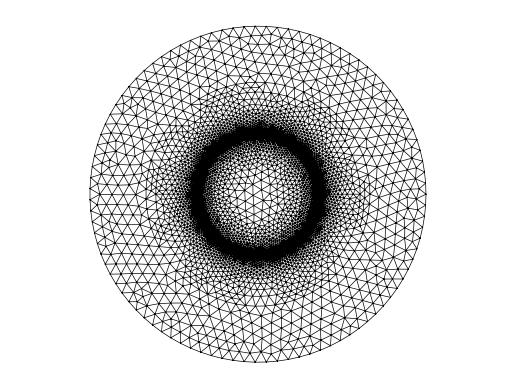

In [6]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

# We have to be careful, the mesh is in mm, but we want to work in SI units (m). So we will scale the mesh by 0.001.
m = meshio.read("mesh/induction_motor.msh")
m.points *= 1e-3  # Scale mesh points from mm to m

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()



In [ ]:
from skfem import Basis, ElementTriP2

e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["Rotor_Yoke"])
basis_rotor_aluminium = basis.with_elements(mesh.subdomains["Rotor_Aluminium"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["Stator_Yoke"])
basis_air_box = basis.with_elements(mesh.subdomains["Air_Box"])
basis_air_holes = basis.with_elements(mesh.subdomains["Air_Hole"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

# Slot to phase current mapping
"""
Slot_1 → A+
Slot_6 → B-
Slot_5 → C+
Slot_4 → A−
Slot_3 → B+
Slot_2 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]


# For example Slot_1 → A+
print(slot_bases[0])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0])
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 626
  Number of DOFs: 25130
  Size: 540864 B

In units of m:  0.0006586781367834658
